In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import phase_mixing_utils
# import PhaseRetrieval
from skimage import color
from skimage.transform import rescale
from scipy.ndimage.filters import gaussian_filter
from skimage import io
from skimage.registration import phase_cross_correlation as register_translation
from simulate_zp import cal_zp
# from simulate_zp_bs import cal_zp_bs, cal_zp_bs_NA
# from tqdm import tqdm
from skimage import io
from probe_prop import propagate
from scipy.ndimage import binary_fill_holes
from skimage.feature import match_template
from pystackreg import StackReg



def _HIOupdate_contrast2(T_old, T_prime, S, beta=0.7):
    """
    Standard HIO update on a complex object/field.

    T_old   : previous estimate (complex)
    T_prime : projected estimate after Fourier-modulus projection (complex)
    S       : support mask (True inside support)
    beta    : HIO relaxation parameter
    """
    S = S.astype(bool)
    T_next = T_prime.copy()
    T_next[S] = T_prime[S]
    T_next[~S] = T_old[~S] - beta * T_prime[~S]
    # T_next[~S] = 0
    return T_next

def HIO_T_ERoutside(T_old, T_prime, S, beta=0.7):
    # support 内 HIO/ER都可；这里保留 T_prime
    T_next = T_old.copy()
    T_next[S]  = T_prime[S]
    T_next[~S] = 0.0 + 0.0j   # 关键：背景对 T 只约束复数值=0，不管相位
    return T_next

def fftc(x):
    N = np.prod(x.shape)
    return np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(x))) / np.sqrt(N)

def ifftc(X):
    N = np.prod(X.shape)
    return np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(X))) * np.sqrt(N)

def threshold_object(O, amp_min=0.7, amp_max=1.2, pha_min=-0.1, pha_max=0.1):
    amp_O = np.abs(O)
    pha_O = np.angle(O)
    
    amp_O[amp_O > amp_max] = amp_max
    amp_O[amp_O < amp_min] = amp_min
    pha_O[pha_O > pha_max] = pha_max
    pha_O[pha_O < pha_min] = pha_min
    
    O_thresholded = amp_O * np.exp(1j * pha_O)
    return O_thresholded



def crop_magnitude_to_probe_xcorr_skimage(
    magnitude: np.ndarray,
    probe: np.ndarray,
    *,
    pad_if_outside: bool = False,
    pad_value: float = 0.0,
) -> tuple[np.ndarray, tuple[int, int], float]:
    """
    Align by normalized cross-correlation (skimage.feature.match_template) and
    crop `magnitude` to the same size as `probe`.

    Parameters
    ----------
    magnitude : np.ndarray
        Larger 2D grayscale image (H1, W1).
    probe : np.ndarray
        Smaller 2D grayscale image (H2, W2) that appears within magnitude.
    pad_if_outside : bool
        If True, returns a probe-sized crop even if the chosen crop goes out of bounds
        by padding with `pad_value`. If False, raises ValueError.
    pad_value : float
        Value used for padding if pad_if_outside=True.

    Returns
    -------
    cropped : np.ndarray
        Cropped region from magnitude with shape == probe.shape.
    top_left : (int, int)
        (row, col) top-left location in magnitude of the best match.
    score : float
        Correlation score at the best match (higher is better).
    """
    if magnitude.ndim != 2 or probe.ndim != 2:
        raise ValueError("Both inputs must be 2D grayscale arrays.")
    H1, W1 = magnitude.shape
    H2, W2 = probe.shape
    if H1 < H2 or W1 < W2:
        raise ValueError("`magnitude` must be at least as large as `probe` in both dimensions.")

    # match_template does normalized cross-correlation.
    # By default, the output has shape (H1-H2+1, W1-W2+1) when pad_input=False.
    corr = match_template(magnitude, probe, pad_input=False)

    # Best match index in correlation map corresponds to top-left corner in magnitude
    r, c = np.unravel_index(np.argmax(corr), corr.shape)
    score = float(corr[r, c])

    r0, c0 = int(r), int(c)
    r1, c1 = r0 + H2, c0 + W2

    if r0 >= 0 and c0 >= 0 and r1 <= H1 and c1 <= W1:
        cropped = magnitude[r0:r1, c0:c1]
        return cropped, (r0, c0), score

    if not pad_if_outside:
        raise ValueError("Best-match crop goes out of bounds. Enable pad_if_outside=True to pad.")

    # Pad magnitude if necessary (rare if magnitude >= probe, but included for completeness)
    pad_top = max(0, -r0)
    pad_left = max(0, -c0)
    pad_bottom = max(0, r1 - H1)
    pad_right = max(0, c1 - W1)

    mag_padded = np.pad(
        magnitude,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=pad_value,
    )

    r0p, c0p = r0 + pad_top, c0 + pad_left
    cropped = mag_padded[r0p:r0p + H2, c0p:c0p + W2]
    return cropped, (r0, c0), score


def average_every_k(stack: np.ndarray, k: int = 20) -> np.ndarray:
    """
    stack: (N, ...) array. Returns averaged stack: (N//k, ...),
    averaging frames [0:k], [k:2k], ...
    Drops remainder if N is not divisible by k.
    """
    n = stack.shape[0]
    m = n // k  # number of full groups
    trimmed = stack[:m * k]
    grouped = trimmed.reshape(m, k, *stack.shape[1:])
    return grouped.mean(axis=1)

def ML_grad_one_iter(prb_O,mask,d):
    phi = np.fft.fftshift(np.fft.fftn(prb_O)) / np.sqrt(np.prod(prb_O.shape))
    dmodel = np.abs(phi)
    # grad =  ((d/d_mean)**2+0.01)/((dmodel/dmodel_mean)**2+0.01) - 1
    grad =  ((d)**2+0.1)/((dmodel)**2+0.1) - 1
    phi_grad = 0.2*grad*phi
    return ((np.fft.ifftn(np.fft.ifftshift(phi_grad)) * np.sqrt(np.prod(prb_O.shape))) *mask)

def single_frame_recon(mags_real, probe_defocus, obj_real, nomask, epoch=5000):
    prb_O = probe_defocus.copy() * obj_real
    for i in range(epoch):
        prb_O += ML_grad_one_iter(prb_O, nomask, mags_real)
    O = prb_O / probe_defocus
    return O

from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift as ndi_shift, convolve

def fill_nan_inf_with_neighbor_average(img, max_iter=20):
    """
    Replace NaN and Inf values using the average of valid neighboring pixels.
    Iteratively fills invalid pixels until all are filled or max_iter is reached.

    Parameters
    ----------
    img : 2D numpy array
        Input grayscale image.
    max_iter : int
        Maximum number of filling iterations.

    Returns
    -------
    filled_img : 2D numpy array
        Image with NaN/Inf replaced by neighbor averages.
    """
    img = np.asarray(img, dtype=np.float32).copy()

    invalid_mask = ~np.isfinite(img)
    if not np.any(invalid_mask):
        return img

    # 8-neighbor kernel, excluding center
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.float32)

    for _ in range(max_iter):
        invalid_mask = ~np.isfinite(img)
        if not np.any(invalid_mask):
            break

        valid_mask = np.isfinite(img).astype(np.float32)

        # temporarily set invalid pixels to 0 for summation
        img_zeroed = np.where(np.isfinite(img), img, 0)

        neighbor_sum = convolve(img_zeroed, kernel, mode='nearest')
        neighbor_count = convolve(valid_mask, kernel, mode='nearest')

        fillable = invalid_mask & (neighbor_count > 0)
        img[fillable] = neighbor_sum[fillable] / neighbor_count[fillable]

    # if anything is still invalid, fill with global mean of valid pixels
    invalid_mask = ~np.isfinite(img)
    if np.any(invalid_mask):
        global_mean = np.mean(img[np.isfinite(img)])
        img[invalid_mask] = global_mean

    return img

def align_grayscale_images(reference_img, moving_img, upsample_factor=100):
    """
    Align moving_img to reference_img.

    Parameters
    ----------
    reference_img : 2D numpy array
        Reference grayscale image.
    moving_img : 2D numpy array
        Moving grayscale image to be aligned.
    upsample_factor : int
        Higher value gives more accurate subpixel shift estimation.

    Returns
    -------
    shifts : tuple
        Estimated shift (row_shift, col_shift).
    aligned_img : 2D numpy array
        Shifted moving image aligned to reference image.
    error : float
        Registration error.
    """
    # make sure inputs are float
    reference_img = reference_img.astype(np.float32)
    moving_img = moving_img.astype(np.float32)

    # estimate shift
    shifts, error, _ = phase_cross_correlation(
        reference_img,
        moving_img,
        upsample_factor=upsample_factor
    )

    # apply shift to moving image
    aligned_img = ndi_shift(moving_img, shift=shifts, order=1, mode='constant', cval=0)

    return shifts, aligned_img, error


def register_2d_translation_pystackreg(img_ref, img_mov, return_matrix=False):
    """
    Register a 2D grayscale moving image to a 2D grayscale reference image
    using pyStackReg translation only.

    Parameters
    ----------
    img_ref : ndarray
        Reference image, shape (H, W).
    img_mov : ndarray
        Moving image to be aligned to img_ref, shape (H, W).
    return_matrix : bool, optional
        If True, also return the estimated transform matrix.

    Returns
    -------
    img_reg : ndarray
        Registered moving image.
    info : dict
        Registration information. If return_matrix=True, includes the
        transform matrix.
    """
    img_ref = np.asarray(img_ref, dtype=np.float32)
    img_mov = np.asarray(img_mov, dtype=np.float32)

    if img_ref.ndim != 2 or img_mov.ndim != 2:
        raise ValueError("Both img_ref and img_mov must be 2D grayscale images.")
    if img_ref.shape != img_mov.shape:
        raise ValueError("img_ref and img_mov must have the same shape.")

    sr = StackReg(StackReg.TRANSLATION)

    # Register moving image to reference image
    img_reg = sr.register_transform(img_ref, img_mov)

    info = {
        "mode": "translation",
    }

    if return_matrix:
        # Get the estimated transform matrix separately
        tmat = sr.register(img_ref, img_mov)
        info["transform_matrix"] = tmat

    return img_reg.astype(np.float32), info

def linear_interpolate_single_frame(img0, img1, alpha):
    """
    Generate a single intermediate frame between img0 and img1 with given alpha.
    alpha=0 gives img0, alpha=1 gives img1.
    """
    frame = (1 - alpha) * img0 + alpha * img1
    return frame


import numpy as np

def match_percentile_range(img_filtered, img_ref, p_low=5, p_high=95, clip=True):
    f_low, f_high = np.percentile(img_filtered, [p_low, p_high])
    r_low, r_high = np.percentile(img_ref, [p_low, p_high])

    if np.isclose(f_high, f_low):
        raise ValueError("Filtered image percentile range is too small.")

    img_out = (img_filtered - f_low) / (f_high - f_low)
    img_out = img_out * (r_high - r_low) + r_low

    if clip:
        img_out = np.clip(img_out, r_low, r_high)

    return img_out


Text(0.5, 1.0, 'zp at detector plane')

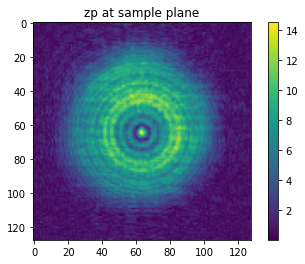

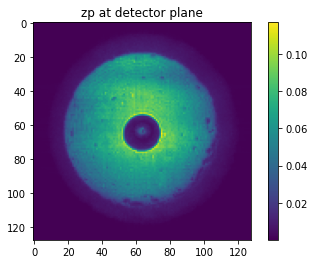

In [57]:


probe_defocus = np.load(r'Ptycho_CDI/S315465/t2_mask/recon_data/recon_315465_t2_mask_probe.npy')
probe_defocus = probe_defocus[0] / np.sqrt(3)



plt.figure()
plt.imshow(np.abs(probe_defocus))
plt.title('zp at sample plane')
plt.colorbar()


ft_probe = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(probe_defocus))) / np.prod(probe_defocus.shape)
plt.figure()
plt.imshow(np.abs(ft_probe))
plt.colorbar()
plt.title('zp at detector plane')




## Generate the obj with the central ptychogrpahy data

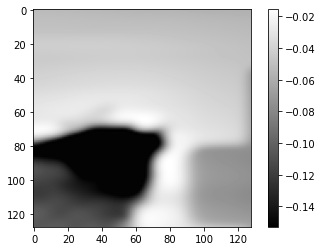

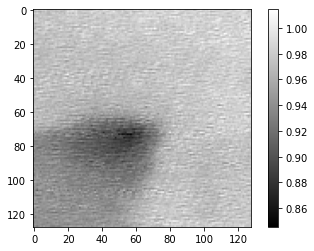

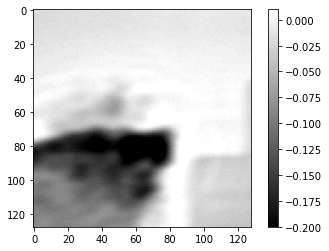

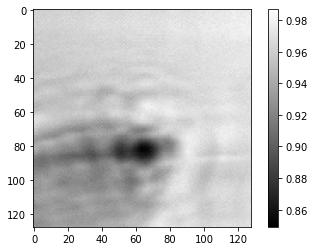

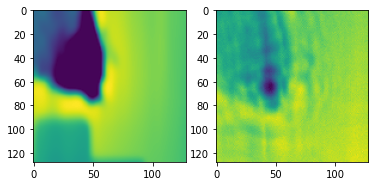

In [58]:
%matplotlib inline
# %matplotlib qt
pha_ini = io.imread(r'Ptycho_CDI/S315463/t2_mask/recon_tif/recon_315463_t2_mask_object_pha0_filtered_median_gray25.tiff')[0]
pha_ini_ref = io.imread(r'Ptycho_CDI/S315463/t2_mask/recon_tif/recon_315463_t2_mask_object_pha0.tif')
pha_ini = match_percentile_range(pha_ini, pha_ini_ref, p_low=5, p_high=95, clip=True)
# plt.figure()    
# plt.imshow(pha_ini-pha_ini_ref, cmap='gray')
# plt.colorbar()

amp_ini = io.imread(r'Ptycho_CDI/S315463/t2_mask/recon_tif/recon_315463_t2_mask_object_amp0_filtered.tif')
amp_ini_ref = io.imread(r'Ptycho_CDI/S315463/t2_mask/recon_tif/recon_315463_t2_mask_object_amp0.tif')
amp_ini = match_percentile_range(amp_ini, amp_ini_ref, p_low=5, p_high=95, clip=True)
# %matplotlib qt
pha_final = io.imread(r'Ptycho_CDI/S315465/t2_mask/recon_tif/recon_315465_t2_mask_object_pha0.tif')
amp_final = io.imread(r'Ptycho_CDI/S315465/t2_mask/recon_tif/recon_315465_t2_mask_object_amp0.tif')



pha_ini, info = register_2d_translation_pystackreg(
    pha_final, pha_ini, return_matrix=True
)
# amp_ini, info = register_2d_translation_pystackreg(
#     amp_final, amp_ini, return_matrix=True
# )
# shift_x = -40
# shift_y = 10
# cy, cx = pha.shape[0]//2 - shift_y, pha.shape[1]//2 - shift_x

# cx, cy = 228+30, 251-65-10

# cx, cy = 258+6, 176-10 # first frame
# # cx, cy = 258, 176 # last frame

cx, cy = 258+6, 176-10 # first frame
# cx, cy = 258, 176 # last frame


pha_ini_crop = pha_ini[cy-64:cy+64, cx-64:cx+64]
amp_ini_crop = amp_ini[cy-64:cy+64, cx-64:cx+64]
pha_final_crop = pha_final[cy-64:cy+64, cx-64:cx+64]
amp_final_crop = amp_final[cy-64:cy+64, cx-64:cx+64]




plt.figure()
plt.imshow(pha_ini_crop, cmap='gray')
plt.colorbar()
plt.figure()
plt.imshow(amp_ini_crop, cmap='gray')
plt.colorbar()
plt.figure()
plt.imshow(pha_final_crop, cmap='gray')
plt.colorbar()
plt.figure()
plt.imshow(amp_final_crop, cmap='gray')
plt.colorbar()


# obj_real = amp_ini_crop * np.exp(1j * pha_ini_crop)
# obj_real = amp * np.exp(1j * pha)
obj_ini = amp_ini_crop * np.exp(1j * pha_ini_crop)
obj_final = amp_final_crop * np.exp(1j * pha_final_crop)
obj_ini = np.rot90(obj_ini, k=-1)
obj_final = np.rot90(obj_final, k=-1)
# obj_real = np.rot90(obj_real, k=-1)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(np.angle(obj_ini))
plt.subplot(1, 2, 2)
plt.imshow(np.abs(obj_final))


# Mask generation

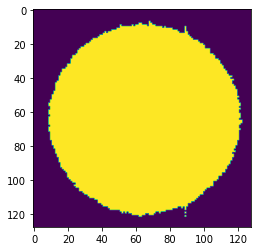

In [59]:
%matplotlib inline
from scipy import ndimage
from skimage.morphology import remove_small_objects

# Pmask = (np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_real/np.max(np.abs(mags_real)))
# Pmask = Pmask > 0.8
# Pmask = binary_fill_holes(Pmask)
# io.imsave('Pmask.tiff', Pmask)

Pmask = io.imread('Pmask.tiff').astype(bool)
Pmask = np.rot90(Pmask, k=-1)

# Smask = pha < -0.06
# Smask = remove_small_objects(Smask, min_size=1000)
# Smask = np.rot90(Smask, k=-1)
# plt.figure()
# plt.imshow(Smask)
# Smask = ndimage.binary_dilation(Smask, iterations=5)
# Smask = remove_small_objects(Smask, min_size=1000)
# Cmask = Smask & Pmask

plt.figure()
plt.imshow(Pmask)

# plt.figure()
# plt.imshow(Smask)

# plt.figure()
# plt.imshow(Cmask)




## Phase retrieval - 1

In [60]:
# %matplotlib inline

# def CDI_phase_retrieval(O=None, mask=None, probe_defocus=None, mags_real=None, epoch=10):

#     bkg_value = 1. * np.exp(1j*(0))
#     mse = []
#     epoch = 10
#     probe_known = probe_defocus.copy() * 1.0
#     for i in range(epoch):
        
#         esw = np.fft.fftshift(np.fft.fftn(O * probe_known)) / np.sqrt(np.prod(O.shape))        
#         esw_prime = mags_real*np.exp(1j*np.angle(esw))
#         esw_back = np.fft.ifftn(np.fft.ifftshift(esw_prime)) * np.sqrt(np.prod(O.shape))    
#         O_prime = esw_back * np.conj(probe_known) / (np.abs(probe_known)**2 + 1e-6)
#         O_prime = threshold_object(O_prime, amp_min=1, amp_max=1.25, pha_min=-0.4, pha_max=0.2)
        
#         T_contrast = O - bkg_value
#         T_contrast_prime = O_prime - bkg_value
#         if i < 20:
#             T_contrast = HIO_T_ERoutside(T_contrast, T_contrast_prime, mask, beta=0.7)
#         else:
#             T_contrast = _HIOupdate_contrast2(T_contrast, T_contrast_prime, mask, beta=0.7) # beta 0.5...
#         O = T_contrast + bkg_value
#         O = threshold_object(O, amp_min=1.00, amp_max=1.25, pha_min=-0.4, pha_max=0.1)

#         mse.append(np.mean((np.abs(fftc(O*probe_defocus)) - mags_real)**2))
#         if i % 10 == 0:
#             bkg_value = np.mean(O[~mask])
            
#     # nomask = np.ones((128,128))
#     # O = single_frame_recon(mags_real, probe_defocus, O, Pmask, epoch=200)

#     return O, mse[-1]



In [61]:
# mags_real_stack = io.imread(r'eiger2_image_315464.tiff')
# mags_real_stack = average_every_k(mags_real_stack, k=160)
# mags_real = mags_real_stack[-1]
# mags_real = np.fliplr(mags_real.T)
# mags_real = np.sqrt(mags_real)
# mags_real, _, _ = crop_magnitude_to_probe_xcorr_skimage(mags_real, np.abs(ft_probe))
# O, mse = CDI_phase_retrieval(O=obj_real, mask=Pmask, probe_defocus=probe_defocus, mags_real=mags_real, epoch=200)

# plt.figure()
# plt.imshow(np.angle(O), vmin=-0.25, vmax=0.1)
# plt.colorbar()
# plt.figure()
# plt.imshow(np.abs(O), vmin=0.9, vmax=1.2)
# plt.colorbar()

# print('Mean Squared Error:', mse)

## Shift of ptycho for ini guess

In [62]:


def fftc(x):
    return np.fft.fftshift(np.fft.fftn(x)) / np.sqrt(np.prod(x.shape))


def ifftc(x):
    return np.fft.ifftn(np.fft.ifftshift(x)) * np.sqrt(np.prod(x.shape))


def crop_complex_object_from_amp_pha(amp, pha, cx, cy, crop_size=128):
    half = crop_size // 2
    y0, y1 = cy - half, cy + half
    x0, x1 = cx - half, cx + half

    if y0 < 0 or x0 < 0 or y1 > amp.shape[0] or x1 > amp.shape[1]:
        return None

    amp_crop = amp[y0:y1, x0:x1]
    pha_crop = pha[y0:y1, x0:x1]
    return amp_crop * np.exp(1j * pha_crop)


def line_shift_candidates(cx0, cy0, cx1, cy1):
    n = int(max(abs(cx1 - cx0), abs(cy1 - cy0))) + 1
    xs = np.rint(np.linspace(cx0, cx1, n)).astype(int)
    ys = np.rint(np.linspace(cy0, cy1, n)).astype(int)

    pts = []
    seen = set()
    for x, y in zip(xs, ys):
        if (x, y) not in seen:
            pts.append((x, y))
            seen.add((x, y))
    return pts


def rectangle_shift_candidates(cx0, cy0, cx1, cy1, step=1):
    xmin, xmax = sorted([cx0, cx1])
    ymin, ymax = sorted([cy0, cy1])

    pts = []
    for cy in range(ymin, ymax + 1, step):
        for cx in range(xmin, xmax + 1, step):
            pts.append((cx, cy))
    return pts


def CDI_phase_retrieval_single(
    O_init,
    mask,
    probe_defocus,
    mags_real,
    epoch=100,
    beta=0.7,
    amp_min=1.00,
    amp_max=1.25,
    pha_min=-0.4,
    pha_max=0.1,
    bkg_update_every=10,
):
    O = O_init.copy()
    probe_known = probe_defocus.copy()
    bkg_value = 1.0 + 0j
    mse = []

    best_O = O.copy()
    best_err = np.inf

    for i in range(epoch):
        esw = fftc(O * probe_known)
        esw_prime = mags_real * np.exp(1j * np.angle(esw))
        esw_back = ifftc(esw_prime)

        O_prime = esw_back * np.conj(probe_known) / (np.abs(probe_known) ** 2 + 1e-6)
        O_prime = threshold_object(
            O_prime,
            amp_min=amp_min,
            amp_max=amp_max,
            pha_min=pha_min,
            pha_max=pha_max,
        )

        T_contrast = O - bkg_value
        T_contrast_prime = O_prime - bkg_value

        if i < -1:
            T_contrast = HIO_T_ERoutside(T_contrast, T_contrast_prime, mask, beta=beta)
        else:
            T_contrast = _HIOupdate_contrast2(T_contrast, T_contrast_prime, mask, beta=beta)


        O = T_contrast + bkg_value
        O = threshold_object(
            O,
            amp_min=amp_min,
            amp_max=amp_max,
            pha_min=pha_min,
            pha_max=pha_max,
        )

        err = np.mean((np.abs(fftc(O * probe_known)) - mags_real) ** 2)
        mse.append(err)

        if err < best_err:
            best_err = err
            best_O = O.copy()

        if (i + 1) % bkg_update_every == 0:
            bkg_value = np.mean(O[~mask])

    return best_O, best_err, mse


def CDI_phase_retrieval_search_final_only(
    amp_final,
    pha_final,
    cx_first,
    cy_first,
    cx_last,
    cy_last,
    mask,
    probe_defocus,
    mags_real,
    epoch=100,
    crop_size=128,
    search_mode="line",   # "line" or "rectangle"
    step=1,
    O_prev=None,          # optional previous reconstructed frame
    temporal_weight=0.0,  # >0 if you want temporal consistency
    verbose=True,
):
    """
    Search different crop centers between first and last frame,
    but only using the final-state object as initial guess.
    """

    if search_mode == "line":
        candidates = line_shift_candidates(cx_first, cy_first, cx_last, cy_last)
    elif search_mode == "rectangle":
        candidates = rectangle_shift_candidates(cx_first, cy_first, cx_last, cy_last, step=step)
    else:
        raise ValueError("search_mode must be 'line' or 'rectangle'")

    all_results = []
    best_score = np.inf
    best_err = np.inf
    best_O = None
    best_center = None
    best_mse = None

    for k, (cx, cy) in enumerate(candidates):
        if verbose:
            print(f"[{k+1}/{len(candidates)}] trying center (cx, cy)=({cx}, {cy})")

        O_init = crop_complex_object_from_amp_pha(
            amp_final, pha_final, cx, cy, crop_size=crop_size
        )
        O_init = np.rot90(O_init, k=-1)
        if O_init is None:
            continue

        O_rec, err, mse = CDI_phase_retrieval_single(
            O_init=O_init,
            mask=mask,
            probe_defocus=probe_defocus,
            mags_real=mags_real,
            epoch=epoch,
        )

        score = err
        if O_prev is not None and temporal_weight > 0:
            score = err + temporal_weight * np.mean(np.abs(O_rec - O_prev) ** 2)

        all_results.append({
            "center": (cx, cy),
            "err": err,
            "score": score,
            "mse": mse,
            "O": O_rec,
        })

        if score < best_score:
            best_score = score
            best_err = err
            best_O = O_rec
            best_center = (cx, cy)
            best_mse = mse

    return {
        "O_best": best_O,
        "best_center": best_center,
        "err_best": best_err,
        "score_best": best_score,
        "mse_best": best_mse,
        "all_results": all_results,
    }
    
    
def CDI_phase_retrieval_final_only_direct(
    amp_final,
    pha_final,
    cx,
    cy,
    mask,
    probe_defocus,
    mags_real,
    epoch=100,
    crop_size=128,
    O_prev=None,          # optional previous reconstructed frame
    temporal_weight=0.0,  # >0 if you want temporal consistency
    verbose=True,
):
    """
    Directly crop the final-state object using the given (cx, cy),
    and use it as the initial guess for CDI reconstruction.

    Parameters
    ----------
    amp_final : ndarray
        Amplitude of the final-state object.
    pha_final : ndarray
        Phase of the final-state object.
    cx, cy : int
        Crop center in the full-size final-state object.
    mask : ndarray
        Support mask for CDI.
    probe_defocus : complex ndarray
        Known probe at object plane.
    mags_real : ndarray
        Measured diffraction magnitude.
    epoch : int
        Number of CDI iterations.
    crop_size : int
        Size of the cropped object.
    O_prev : complex ndarray or None
        Previous reconstructed frame, optional.
    temporal_weight : float
        Weight for temporal consistency term.
    verbose : bool
        Whether to print progress.

    Returns
    -------
    result : dict
        Dictionary containing reconstruction results.
    """

    if verbose:
        print(f"Using direct crop center (cx, cy)=({cx}, {cy})")

    O_init = crop_complex_object_from_amp_pha(
        amp_final, pha_final, cx, cy, crop_size=crop_size
    )

    if O_init is None:
        raise ValueError(f"Invalid crop at (cx, cy)=({cx}, {cy}) with crop_size={crop_size}")

    O_init = np.rot90(O_init, k=-1)

    O_rec, err, mse = CDI_phase_retrieval_single(
        O_init=O_init,
        mask=mask,
        probe_defocus=probe_defocus,
        mags_real=mags_real,
        epoch=epoch,
    )

    score = err
    # temporal_term = None
    # if O_prev is not None and temporal_weight > 0:
    #     temporal_term = np.mean(np.abs(O_rec - O_prev) ** 2)
    #     score = err + temporal_weight * temporal_term

    return {
        "O_init": O_init,
        "O_best": O_rec,
        "center": (cx, cy),
        "err": err,
        "score": score,
        "mse": mse,
    }
    
def exact_diagonal_path(cx_first=266, cy_first=165,
                    cx_last=258, cy_last=173):
    """
    Return all integer points on the 45-degree line segment.
    """
    step = abs(cx_last - cx_first) + 1
    cx_vals = np.linspace(cx_first, cx_last, step, dtype=int)
    cy_vals = np.linspace(cy_first, cy_last, step, dtype=int)
    return list(zip(cx_vals, cy_vals))


def linear_path_coordinates(cx_first=266, cy_first=165,
                            cx_last=258, cy_last=173,
                            n_frames=37):
    """
    Generate integer crop centers along the linear path from
    (cx_first, cy_first) to (cx_last, cy_last), inclusive.

    Parameters
    ----------
    cx_first, cy_first : int
        Start coordinate.
    cx_last, cy_last : int
        End coordinate.
    n_frames : int
        Total number of frames, including first and last.

    Returns
    -------
    coords : list of tuple
        List of (cx, cy) integer coordinates.
    """
    if n_frames < 2:
        raise ValueError("n_frames must be at least 2.")

    cx_vals = np.linspace(cx_first, cx_last, n_frames)
    cy_vals = np.linspace(cy_first, cy_last, n_frames)

    coords = [(int(round(cx)), int(round(cy))) for cx, cy in zip(cx_vals, cy_vals)]
    return coords

def ML_grad_one_iter(prb_O,mask,d):
    phi = np.fft.fftshift(np.fft.fftn(prb_O)) / np.sqrt(np.prod(prb_O.shape))
    dmodel = np.abs(phi)
    # grad =  ((d/d_mean)**2+0.01)/((dmodel/dmodel_mean)**2+0.01) - 1
    grad =  ((d)**2+0.1)/((dmodel)**2+0.1) - 1
    phi_grad = 0.2*grad*phi
    return ((np.fft.ifftn(np.fft.ifftshift(phi_grad)) * np.sqrt(np.prod(prb_O.shape))) *mask)

def single_frame_recon(mags_real, probe_defocus, obj_real, nomask, num_epoch=5000):
    prb_O = probe_defocus.copy() * obj_real
    for i in range(num_epoch):
        prb_O += ML_grad_one_iter(prb_O, nomask, mags_real)
    O = prb_O / probe_defocus
    return O


## single test

In [63]:
cx_first, cy_first = 266, 165
cx_last,  cy_last  = 256, 171

mags_real_stack = io.imread(r'eiger2_image_315464.tiff')
mags_real_stack = average_every_k(mags_real_stack, k=160)
n_frames = mags_real_stack.shape[0]

# cxy_vals = exact_diagonal_path(cx_first, cy_first, cx_last, cy_last)
cxy_vals = linear_path_coordinates(cx_first, cy_first, cx_last, cy_last, n_frames=n_frames)
# print(cxy_vals)
cxy_vals[0][0]

266

Using direct crop center (cx, cy)=(266, 165)


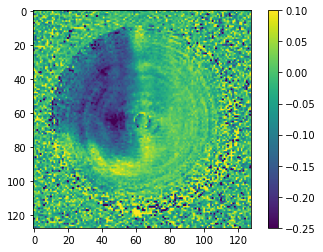

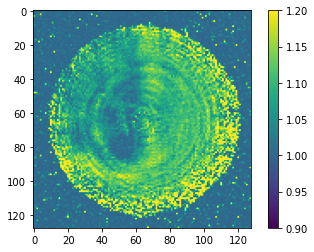

In [64]:
# cx_first, cy_first = 258 + 6, 176 - 10
# cx_last,  cy_last  = 258, 176

# cx_first, cy_first = 258 + 6 + 2, 176 - 10 - 2 
# cx_last,  cy_last  = 258 - 2, 176 + 2

cx_first, cy_first = 266, 165
cx_last,  cy_last  = 258, 173

cxy_vals = exact_diagonal_path(cx_first, cy_first, cx_last, cy_last)


mags_real_stack = io.imread(r'eiger2_image_315464.tiff')
mags_real_stack = average_every_k(mags_real_stack, k=160)
mags_real = mags_real_stack[-1]
mags_real = np.fliplr(mags_real.T)
mags_real = np.sqrt(mags_real)
mags_real, _, _ = crop_magnitude_to_probe_xcorr_skimage(mags_real, np.abs(ft_probe))


result = CDI_phase_retrieval_final_only_direct(
    amp_final=amp_final,
    pha_final=pha_final,
    cx=cxy_vals[0][0],
    cy=cxy_vals[0][1],
    mask=Pmask,
    probe_defocus=probe_defocus,
    mags_real=mags_real,
    epoch=200,
    crop_size=128,
)

O_best = result["O_best"]


plt.figure()
plt.imshow(np.angle(O_best), vmin=-0.25, vmax=0.1)
plt.colorbar()
plt.figure()
plt.imshow(np.abs(O_best), vmin=0.9, vmax=1.2)
plt.colorbar()

## batch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io


def mse_to_psnr(mse, data_range=1.0):
    """
    Convert MSE to PSNR:
        PSNR = 10 * log10((data_range^2) / mse)

    If mse == 0, returns +inf.
    """
    mse = float(mse)
    if mse <= 0:
        return np.inf
    return 10.0 * np.log10((data_range ** 2) / mse)


def preprocess_mags_stack(mags_real_stack_raw, ft_probe):
    """
    Apply the same preprocessing to every diffraction frame:
      - fliplr + transpose
      - sqrt
      - crop to probe
    """
    mags_processed = []
    for frame in mags_real_stack_raw:
        mags_real = np.fliplr(frame.T)
        mags_real = np.sqrt(mags_real)
        mags_real, _, _ = crop_magnitude_to_probe_xcorr_skimage(
            mags_real, np.abs(ft_probe)
        )
        mags_processed.append(mags_real)
    return np.asarray(mags_processed)


# ======================================
# user-defined crop search range
# ======================================
# cx_first, cy_first = 258 + 6 + 2, 176 - 10 - 2
# cx_last,  cy_last  = 258 - 2,     176 + 2

cx_first, cy_first = 266, 165
cx_last,  cy_last  = 258-2, 173-2

# ======================================
# load and preprocess diffraction stack
# ======================================
binning = 5
mags_real_stack = io.imread(r'eiger2_image_315464.tiff')
mags_real_stack = average_every_k(mags_real_stack, k=binning)

mags_processed_stack = preprocess_mags_stack(mags_real_stack, ft_probe)

# Use one common data range for PSNR across all slices
# so the PSNR values are comparable frame to frame.
global_data_range = float(np.max(mags_processed_stack))

print("processed stack shape:", mags_processed_stack.shape)
print("PSNR data range:", global_data_range)

# ======================================
# reconstruct every slice
# ======================================
cdi_movie = []
best_centers = []
best_errs = []
best_psnrs = []
all_results = []

# optional: use previous reconstruction for temporal consistency
use_temporal_consistency = False
temporal_weight = 0.0
O_prev = None

for i, mags_real in enumerate(mags_processed_stack):
    print(f"\n===== reconstructing slice {i+1}/{len(mags_processed_stack)} =====")

    result = CDI_phase_retrieval_final_only_direct(
        amp_final=amp_final,
        pha_final=pha_final,
        cx=cxy_vals[i][0], #cx=cxy_vals[i][0]
        cy=cxy_vals[i][1], #cy=cxy_vals[i][1]
        mask=Pmask,
        probe_defocus=probe_defocus,
        mags_real=mags_real,
        epoch=200,
        crop_size=128,
    )

    O_best = result["O_best"]
    
    nomask = np.ones((128,128))
    O_best = single_frame_recon(mags_real, probe_defocus, O_best, nomask, num_epoch=500)



    cdi_movie.append(O_best)
    all_results.append(result)
    
    if i > 4:
        break
    
    




cdi_movie = np.asarray(cdi_movie)
best_errs = np.asarray(best_errs)
best_psnrs = np.asarray(best_psnrs)

# centers as arrays
best_cx = np.array([c[0] for c in best_centers])
best_cy = np.array([c[1] for c in best_centers])

print("\nDone.")
print("cdi_movie shape:", cdi_movie.shape)

processed stack shape: (1200, 128, 128)
PSNR data range: 17.372390747070312

===== reconstructing slice 1/1200 =====
Using direct crop center (cx, cy)=(266, 165)

===== reconstructing slice 2/1200 =====
Using direct crop center (cx, cy)=(266, 165)

===== reconstructing slice 3/1200 =====
Using direct crop center (cx, cy)=(266, 165)

===== reconstructing slice 4/1200 =====
Using direct crop center (cx, cy)=(266, 165)

===== reconstructing slice 5/1200 =====
Using direct crop center (cx, cy)=(266, 165)

===== reconstructing slice 6/1200 =====
Using direct crop center (cx, cy)=(266, 165)

Done.
cdi_movie shape: (6, 128, 128)


In [73]:
cdi_movie_abs = [np.rot90(np.abs(frame), k=1) for frame in cdi_movie]
cdi_movie_pha = [np.rot90(np.angle(frame), k=1) for frame in cdi_movie]
# plt.figure()
# plt.imshow(cdi_movie_abs[0], vmin=0.9, vmax=1.2)
# plt.colorbar()
# plt.figure()
# plt.imshow(cdi_movie_pha[0], vmin=-0.25, vmax=0.1)
# plt.colorbar()
io.imsave(rf'cdi_movie_amp_shift_bin{binning}_linear2_ML_HIO_bt.tiff', np.array(cdi_movie_abs).astype(np.float32))
io.imsave(rf'cdi_movie_pha_shift_bin{binning}_linear2_ML_HIO_bt.tiff', np.array(cdi_movie_pha).astype(np.float32))

## paper figure

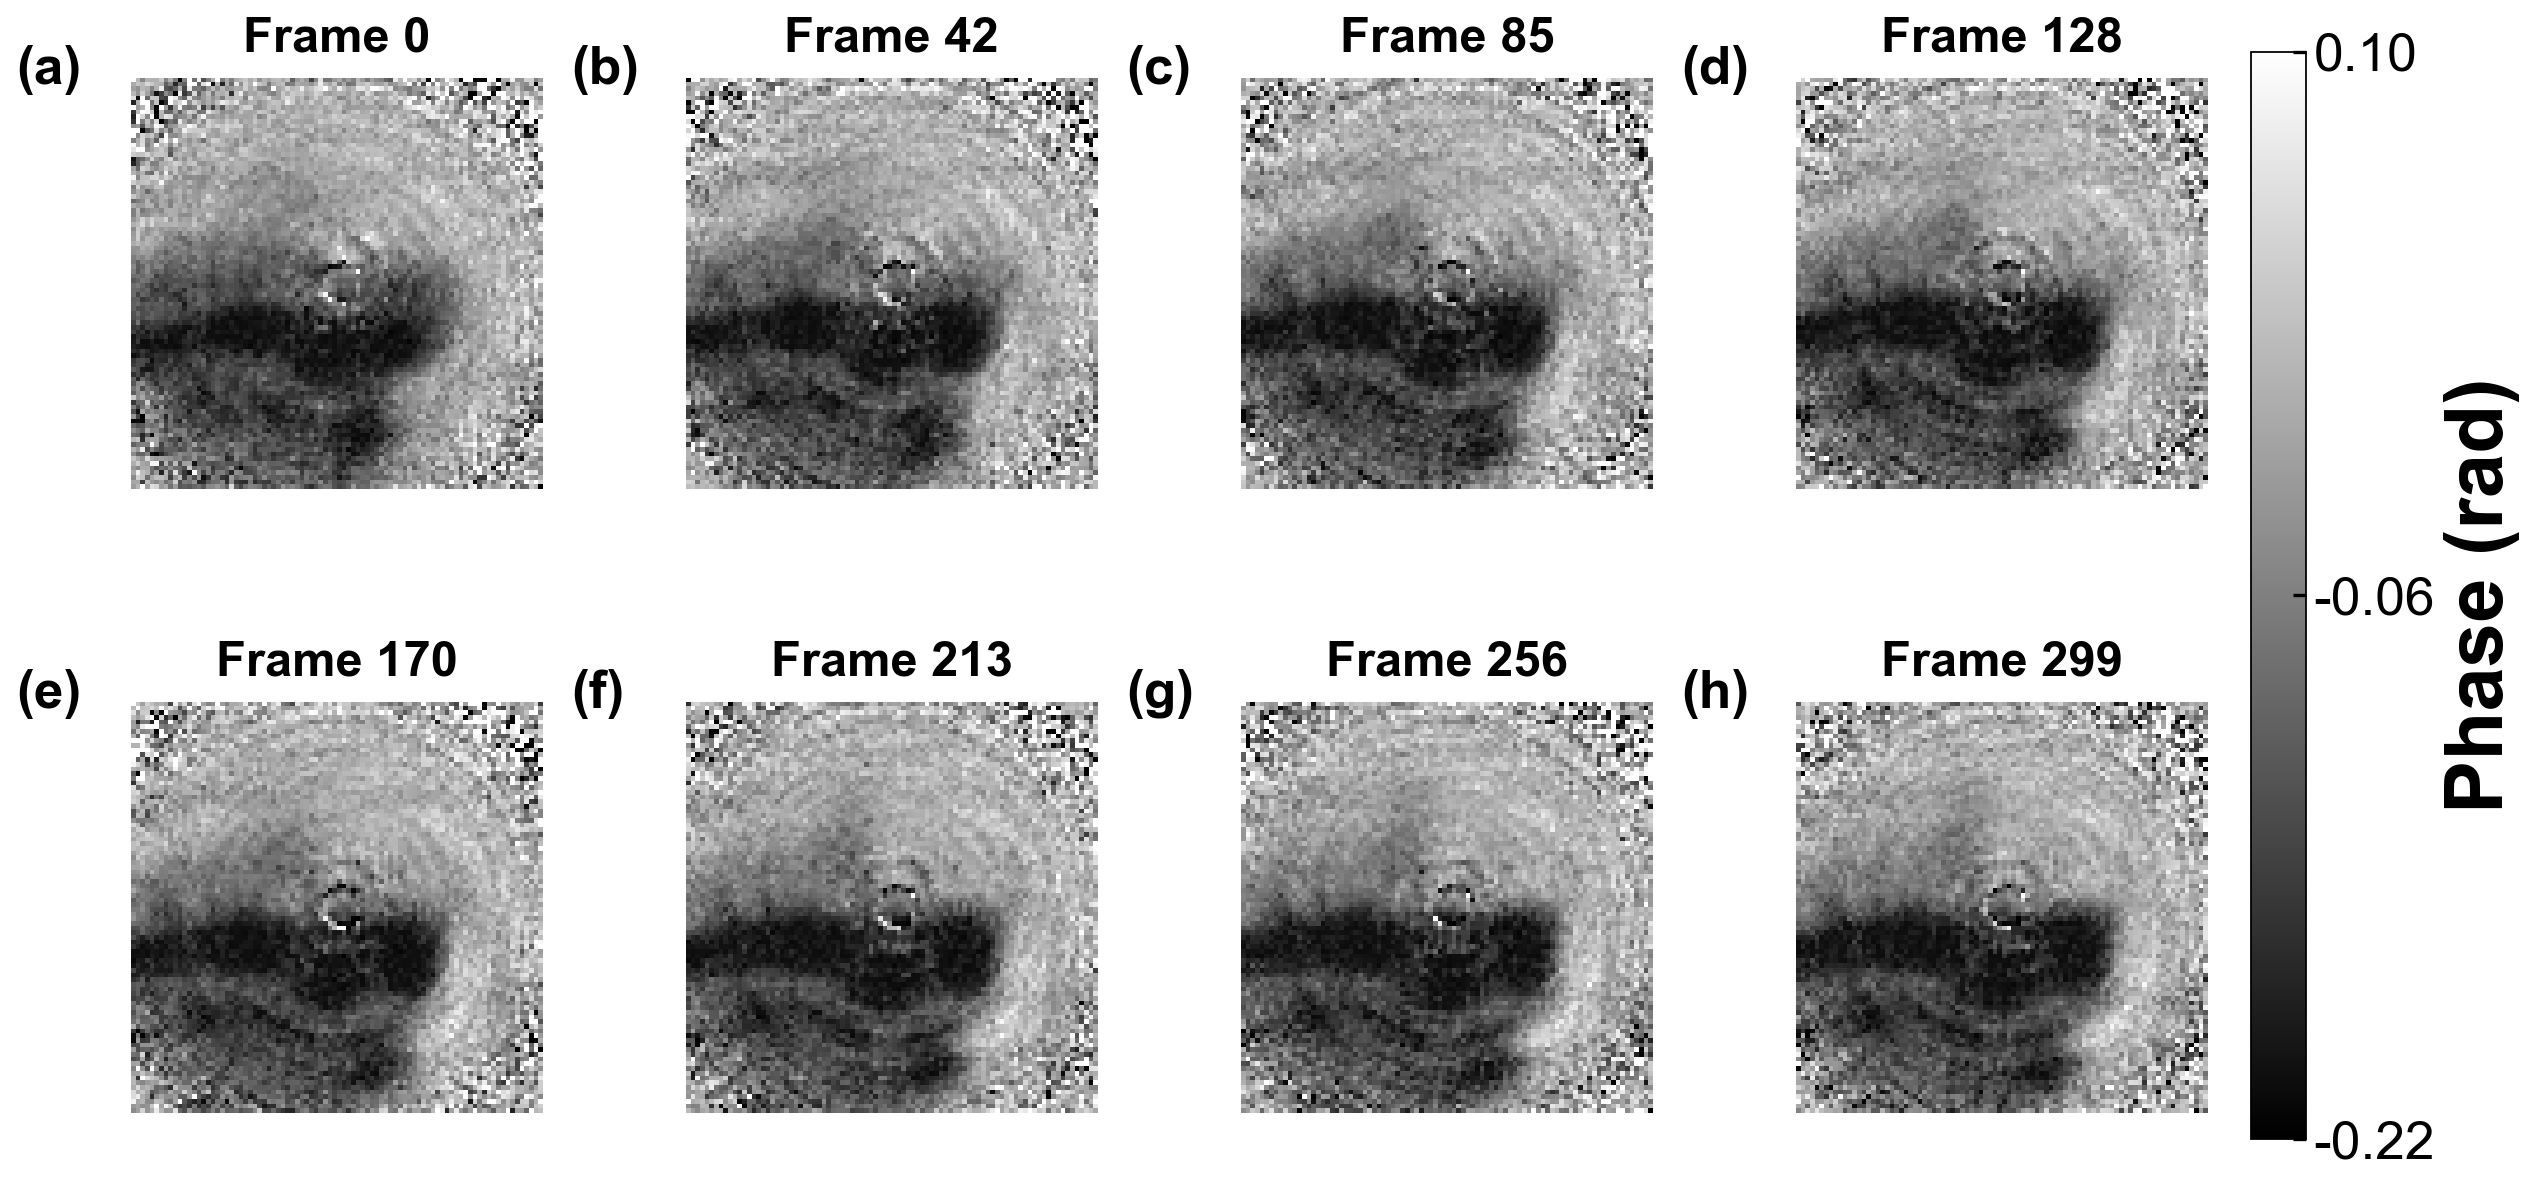

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# Optional styling
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
})

title_kw = dict(fontweight='bold', fontsize=22)
cbar_label_kw = dict(fontweight='bold', fontsize=36)

def add_panel_label(ax, label):
    ax.text(
        -0.28, 1.08, label,
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=24, fontweight='bold',
        color='black',
        clip_on=False
    )

def style_colorbar(cbar, label, fmt='{:.2f}'):
    cbar.set_label(label, **cbar_label_kw)
    cbar.ax.tick_params(labelsize=24, direction='in', length=6, width=1.5)

    vmin, vmax = cbar.mappable.get_clim()
    vmid = 0.5 * (vmin + vmax)
    ticks = [vmin, vmid, vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([fmt.format(t) for t in ticks])

# =========================
# parameters
# =========================
border = 20
n_show = 8

# if cdi_movie_pha is complex, use:
# stack = np.angle(cdi_movie_pha)
stack = np.asarray(cdi_movie_pha)

n_frames = stack.shape[0]
frame_idx = np.linspace(0, n_frames - 1, min(n_show, n_frames), dtype=int)

def crop_img(img, border=0):
    if border <= 0:
        return img
    return img[border:-border, border:-border]

imgs = [crop_img(stack[i], border=border) for i in frame_idx]

# common color scale
vmin = -0.22 #min(np.min(img) for img in imgs)
vmax = 0.1 #max(np.max(img) for img in imgs)

# if you want fixed scale instead, use:
# vmin, vmax = -0.12, 0.10

fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=False)
axes = axes.ravel()

fig.subplots_adjust(hspace=0.35, wspace=0.35, right=0.88)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

im = None
for j, ax in enumerate(axes):
    if j < len(imgs):
        im = ax.imshow(imgs[j], cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f'Frame {frame_idx[j]}', **title_kw, pad=12)
        ax.axis('off')
        add_panel_label(ax, panel_labels[j])
    else:
        ax.axis('off')

# one shared colorbar
cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.02)
style_colorbar(cbar, 'Phase (rad)', fmt='{:.2f}')

plt.show()

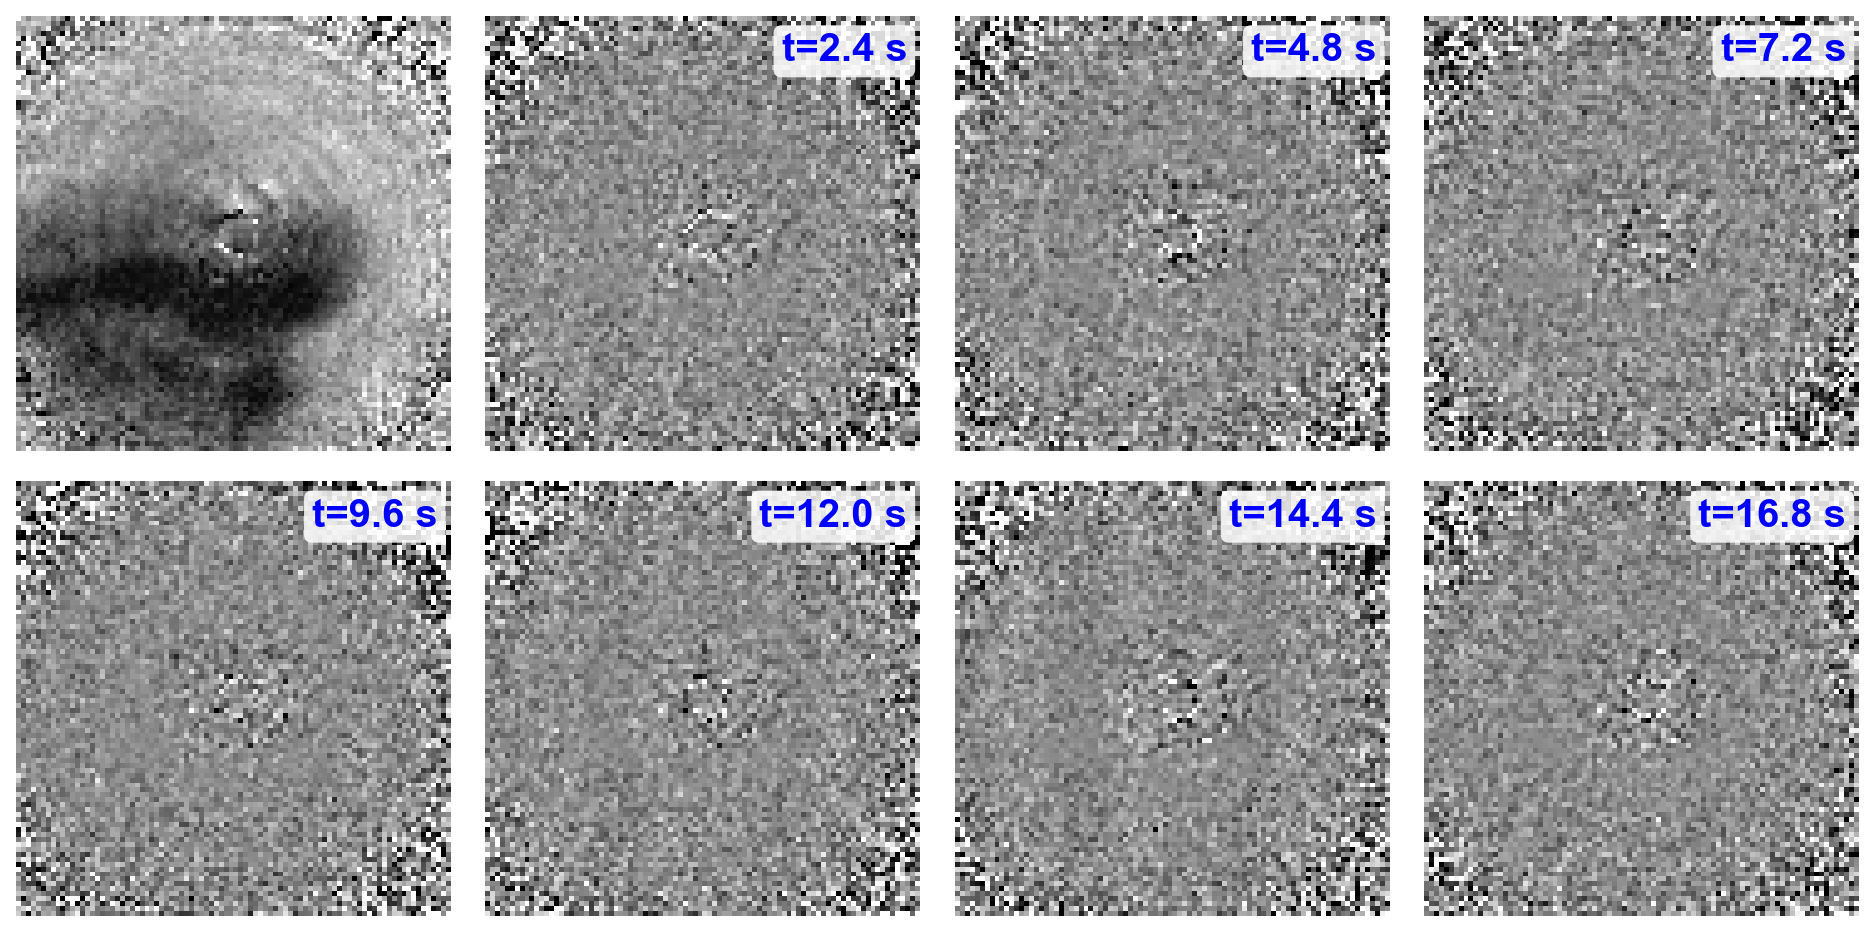

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Optional styling
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
})

time_kw = dict(
    color='blue',
    fontsize=18,
    fontweight='bold',
    ha='right',
    va='top'
)

# =========================
# parameters
# =========================
border = 20
n_show = 8

# if cdi_movie_pha is complex, use:
stack = np.angle(cdi_movie_pha)
# stack = io.imread('cdi_movie_pha_bin160_hybrid_gray25.tiff')
stack = np.asarray(cdi_movie_pha)
stack = stack[:22]

n_frames = stack.shape[0]
frame_idx = np.linspace(0, n_frames - 1, min(n_show, n_frames), dtype=int)

def crop_img(img, border=0):
    if border <= 0:
        return img
    return img[border:-border, border:-border]

imgs = [crop_img(stack[i], border=border) for i in frame_idx]

# common display range for all images
vmin = -0.22
vmax = 0.1

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

# make panels compact
fig.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.02,
    top=0.98,
    wspace=0.08,
    hspace=0.02
)

for j, ax in enumerate(axes):
    if j == 0:
        im = ax.imshow(imgs[j], cmap='gray', vmin=vmin, vmax=vmax)
    if 0< j < len(imgs):
        im = ax.imshow(imgs[j] - imgs[0], cmap='gray', vmin=vmin, vmax=vmax)
            
        ax.axis('off')

        t_val = 800 * frame_idx[j] / 1000
        ax.text(
            0.97, 0.96,
            f't={t_val} s',
            transform=ax.transAxes,
            **time_kw,
            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.85,
                boxstyle='round,pad=0.2'
            )
        )
    else:
        ax.axis('off')

plt.show()

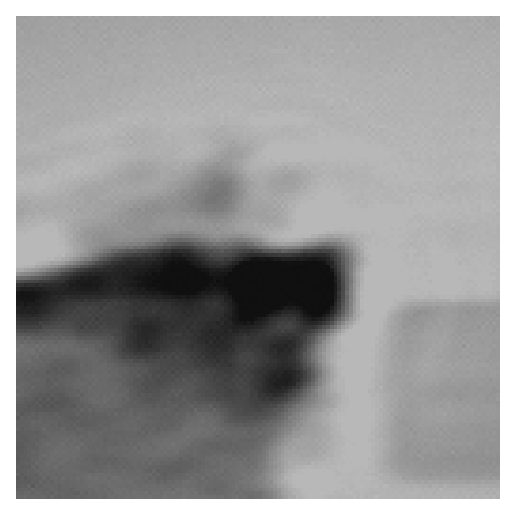

In [121]:
plt.figure()
plt.imshow(np.rot90(np.angle(obj_real)), vmin=-0.22, vmax=0.1, cmap='gray')
plt.axis('off')
io.imsave('cdi_movie_pha_bin20_hybrid.tiff', np.float32(cdi_movie_pha))

## different exposure time results

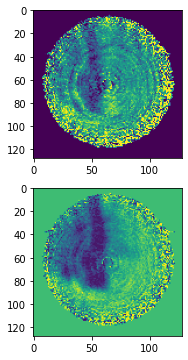

In [20]:
mags_real_stack = io.imread(r'eiger2_image_315464.tiff')
mags_real_stack = average_every_k(mags_real_stack, k=20)
cdi_movie = []
mags_real = mags_real_stack[-1]    
mags_real = np.fliplr(mags_real.T)
mags_real = np.sqrt(mags_real)
mags_real, _, _ = crop_magnitude_to_probe_xcorr_skimage(mags_real, np.abs(ft_probe))

O = CDI_phase_retrieval(O=obj_real, mask=Pmask, probe_defocus=probe_defocus, mags_real=mags_real, epoch=10)
cdi_movie.append(O)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.imshow(np.abs(O), vmin=1, vmax=1.2)
# plt.title('Amp', fontdict={'fontsize': 24, 'fontweight': 'bold'})
# plt.imshow(np.abs(real_space_guess))
# plt.colorbar()

plt.subplot(2, 1, 2)
plt.imshow(np.angle(O), vmin=-0.22, vmax=0.1)
# plt.title('Phase', fontdict={'fontsize': 24, 'fontweight': 'bold'})
# plt.imshow(np.angle(new_real_space))
# plt.colorbar()

## paper figure

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# =========================
# Plot style
# =========================
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 18,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
})

title_kw = dict(fontweight='bold', fontsize=20)

def style_colorbar(cbar, label, fmt='{:.2f}', labelsize=16, ticksize=14):
    cbar.set_label(label, fontsize=labelsize, fontweight='bold')
    cbar.ax.tick_params(labelsize=ticksize, width=1.5, length=5)

    vmin, vmax = cbar.mappable.get_clim()
    vmid = 0.5 * (vmin + vmax)
    ticks = [vmin, vmid, vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([fmt.format(t) for t in ticks])

# =========================
# Parameters
# =========================
file_path = r'eiger2_image_315464.tiff'
binning_list = [1, 2,3,4,5, 10, 160, 6000]

# fixed display range for fair comparison
pha_vmin, pha_vmax = -0.22, 0.10

# optional crop border in object space display
border = 0   # e.g. 20 if you want to crop edges after reconstruction

# =========================
# Helper
# =========================
def crop_img(img, border=0):
    if border <= 0:
        return img
    return img[border:-border, border:-border]

def reconstruct_one_binning(raw_stack, k, obj_real, Pmask, probe_defocus, ft_probe, epoch=10):
    """
    Reconstruct one CDI result for a given temporal binning k.
    Uses the last averaged frame after binning.
    """
    if k == 1:
        stack_binned = raw_stack
    else:
        stack_binned = average_every_k(raw_stack, k=k)

    mags_real = stack_binned[-1]
    mags_real = np.fliplr(mags_real.T)
    mags_real = np.sqrt(mags_real)
    mags_real, _, _ = crop_magnitude_to_probe_xcorr_skimage(mags_real, np.abs(ft_probe))

    O_rec = CDI_phase_retrieval(
        O=obj_real.copy(),
        mask=Pmask,
        probe_defocus=probe_defocus,
        mags_real=mags_real,
        epoch=epoch
    )
    return np.rot90(O_rec)

# =========================
# Load data and reconstruct
# =========================
raw_stack = io.imread(file_path)

results = []
for k in binning_list:
    O_rec = reconstruct_one_binning(
        raw_stack=raw_stack,
        k=k,
        obj_real=obj_real,
        Pmask=Pmask,
        probe_defocus=probe_defocus,
        ft_probe=ft_probe,
        epoch=5
    )
    results.append(O_rec)


# optional save
# fig.savefig('CDI_binning_phase_comparison.png', bbox_inches='tight')
# fig.savefig('CDI_binning_phase_comparison.pdf', bbox_inches='tight')

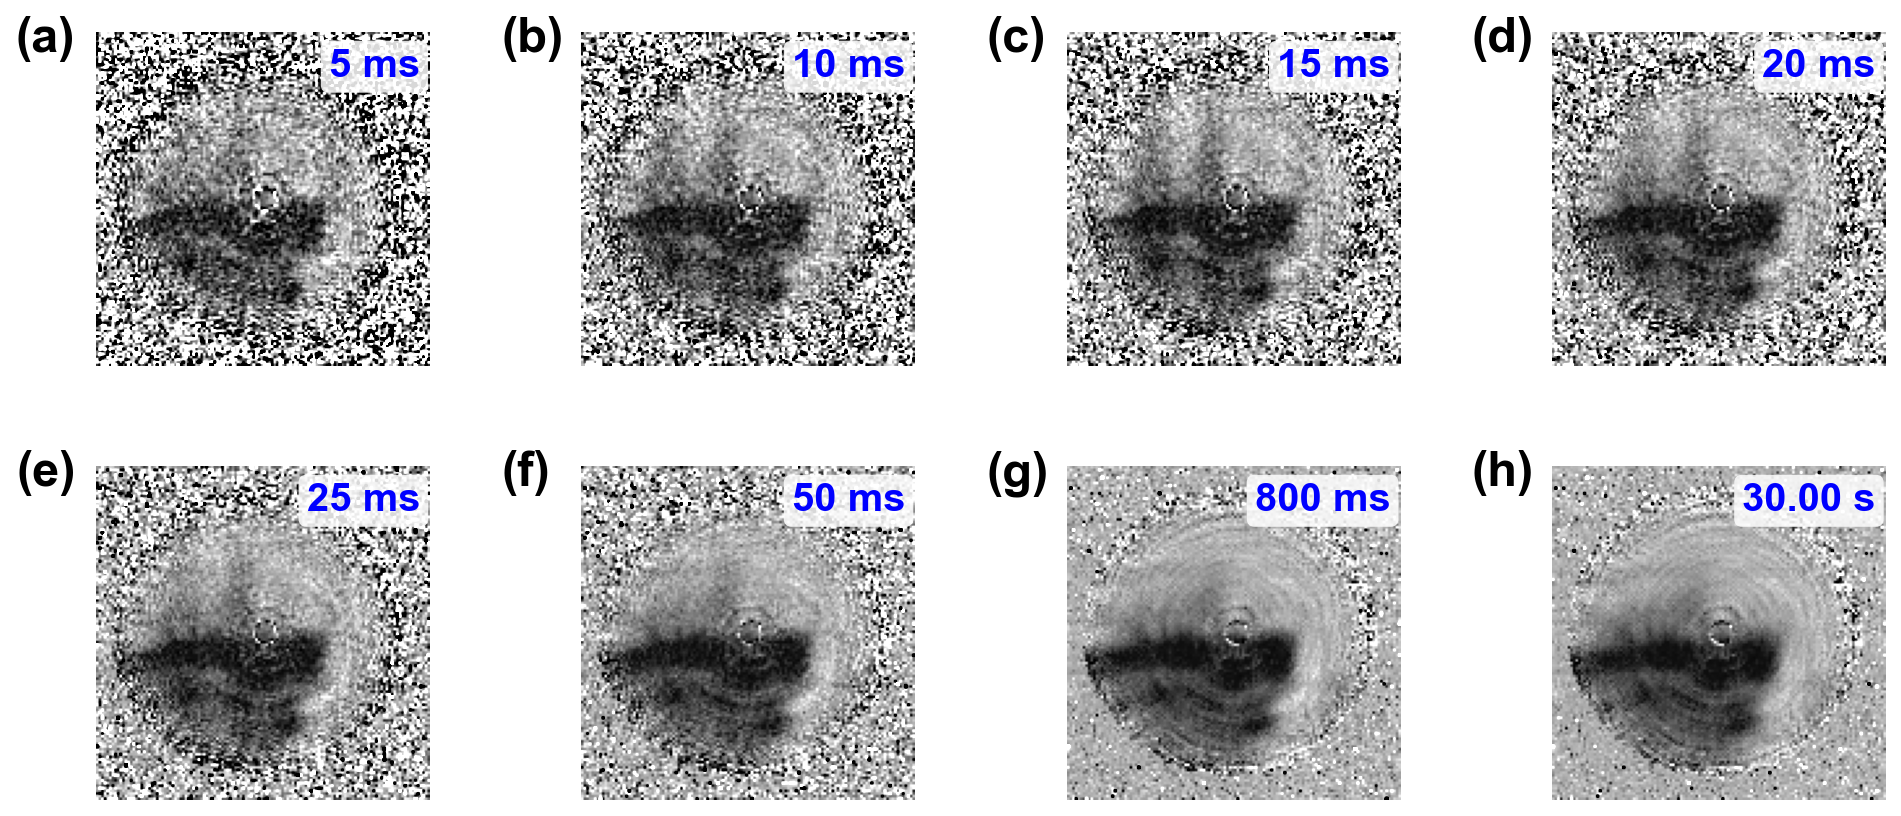

In [105]:
# =========================
# Plot
# =========================
import math

def add_panel_label(ax, label):
    ax.text(
        -0.24, 1.05, label,
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=22, fontweight='bold',
        color='black',
        clip_on=False
    )

def format_exposure_time(binning, base_ms=5):
    exp_time_ms = base_ms * binning
    if exp_time_ms < 1000:
        return f'{exp_time_ms} ms'
    else:
        return f'{exp_time_ms/1000:.2f} s'

def add_exposure_text(ax, binning, base_ms=5):
    txt = format_exposure_time(binning, base_ms=base_ms)
    ax.text(
        0.97, 0.95,
        txt,
        transform=ax.transAxes,
        va='top', ha='right',
        fontsize=18,
        fontweight='bold',
        color='blue',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
            boxstyle='round,pad=0.2'
        )
    )

n_items = len(binning_list)
nrows = 2
ncols = math.ceil(n_items / nrows)

fig_width = 3.2 * ncols
fig_height = 4.8 * nrows / 1.6
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), constrained_layout=False)

# flatten axes for easy indexing
axes = np.array(axes).ravel()

fig.subplots_adjust(left=0.02, right=0.90, top=0.88, bottom=0.08, wspace=0.4, hspace=0.3)

panel_labels = [f'({chr(97+i)})' for i in range(n_items)]

pha_im = None
for i, (k, O_rec) in enumerate(zip(binning_list, results)):
    pha = crop_img(np.angle(O_rec), border=border)

    ax = axes[i]
    pha_im = ax.imshow(pha, cmap='gray', vmin=pha_vmin, vmax=pha_vmax)
    ax.axis('off')
    add_panel_label(ax, panel_labels[i])
    add_exposure_text(ax, k, base_ms=5)

# turn off unused axes
for j in range(n_items, len(axes)):
    axes[j].axis('off')

plt.show()